# 04 — Segment Analysis and Ordered Robustness

This notebook contains the actual segment-transfer and expanding-window robustness code. The segment balance threshold is learned from training data within validation, and forward test blocks must meet the stricter minimum-size/positive/negative gate.

## 1. Setup, models and ordered-period definition

In [1]:
from pathlib import Path
from inspect import signature
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, brier_score_loss
warnings.filterwarnings('ignore')
SEED=42; MIN_TRAIN=5000; MIN_POS=100; MIN_NEG=100; AGE_CUTOFF=71
DATA=Path('data/term-deposit-marketing-2020.csv'); TUNE=Path('results/baseline_tuning'); IMB=Path('results/features_imbalance'); OUT=Path('results/segments_robustness'); FIG=Path('figures/segments_robustness')
OUT.mkdir(parents=True,exist_ok=True); FIG.mkdir(parents=True,exist_ok=True)
NUM=['age','balance','day','campaign']; CAT=['job','marital','education','default','housing','loan','contact','month']; FEATURES=NUM+CAT; PROFILE=['age','job','marital','education','balance']
CV=StratifiedKFold(5,shuffle=True,random_state=SEED); GCV=StratifiedGroupKFold(5,shuffle=True,random_state=SEED)

def prep(): return ColumnTransformer([('n',StandardScaler(),NUM),('c',OneHotEncoder(handle_unknown='ignore',sparse_output=False),CAT)])
def lr_model(p):
    q=p.copy(); pen=q.pop('penalty','l2')
    if signature(LogisticRegression).parameters['penalty'].default=='deprecated': q['l1_ratio']=1.0 if pen=='l1' else 0.0
    else: q['penalty']=pen
    return LogisticRegression(solver=q.pop('solver','liblinear'),max_iter=3000,random_state=SEED,**q)
def model(name,p): return lr_model(p) if name=='LR' else HistGradientBoostingClassifier(random_state=SEED,**p)
def pipe(name,p): return Pipeline([('preprocess',prep()),('model',model(name,p))])
def baseline(name): return LogisticRegression(C=1.0,max_iter=100,random_state=SEED) if name=='LR' else HistGradientBoostingClassifier(loss='log_loss',learning_rate=.1,max_iter=100,max_leaf_nodes=31,max_depth=None,min_samples_leaf=20,l2_regularization=0,max_bins=255,early_stopping='auto',class_weight=None,random_state=SEED)
def metrics(yt,p):
    z=(p>=.5).astype(int); return {'n_rows':len(yt),'base_rate':float(np.mean(yt)),'accuracy':accuracy_score(yt,z),'precision':precision_score(yt,z,zero_division=0),'recall':recall_score(yt,z,zero_division=0),'f1':f1_score(yt,z,zero_division=0),'roc_auc':roc_auc_score(yt,p),'pr_auc':average_precision_score(yt,p),'brier':brier_score_loss(yt,p)}
def oof(est,X,y,cv=CV,groups=None):
    p=cross_val_predict(est,X,y,cv=cv,groups=groups,method='predict_proba',n_jobs=-1)[:,1]; return p,metrics(y,p)
def segment_mask(d,q3): return d.contact.astype(str).str.lower().eq('cellular') & (d.job.astype(str).str.lower().eq('retired') | d.age.ge(AGE_CUTOFF) | d.balance.ge(q3))
def wmean(x,w): return np.average(x,weights=w)
def wsd(x,w):
    if len(x)<2:return np.nan
    m=wmean(x,w); return np.sqrt(np.average((np.asarray(x)-m)**2,weights=w))

df=pd.read_csv(DATA); df['y_binary']=df.y.eq('yes').astype(int); df['row_order']=np.arange(len(df)); df['period_id']=df.month.astype(str).ne(df.month.astype(str).shift()).cumsum(); df['period_label']=df.apply(lambda r:f"P{int(r.period_id):02d}-{r.month}",axis=1)
y=df.y_binary.to_numpy(); X=df[FEATURES]; groups=df.groupby(PROFILE,dropna=False,sort=False).ngroup(); T=json.loads((TUNE/'selected_precall_params.json').read_text()); U=json.loads((IMB/'unweighted_precall_params.json').read_text())

## 2. Exploratory higher-conversion population and transferred model settings

In [2]:
q3_full=df.balance.quantile(.75); descriptive=segment_mask(df,q3_full); seg=df[descriptive]
segment_summary=pd.DataFrame([{'customers':len(seg),'subscribers':int(seg.y_binary.sum()),'subscription_rate':seg.y_binary.mean(),'balance_q3_full_data':q3_full,'age_cutoff':AGE_CUTOFF,'status':'exploratory data-derived segment; full-data summary only'}]); segment_summary.to_csv(OUT/'segment_summary.csv',index=False)

def segment_oof(name,stage):
    truth=[]; prob=[]; meta=[]
    for fold,(tr,te) in enumerate(CV.split(X,y),1):
        dtr=df.iloc[tr]; dte=df.iloc[te]; q3=dtr.balance.quantile(.75); mtr=segment_mask(dtr,q3); mte=segment_mask(dte,q3)
        if mtr.sum()==0 or mte.sum()==0 or dtr.loc[mtr,'y_binary'].nunique()<2 or dte.loc[mte,'y_binary'].nunique()<2: continue
        est=Pipeline([('preprocess',prep()),('model',baseline(name))]) if stage=='Baseline' else pipe(name,T[name]); est.fit(dtr.loc[mtr,FEATURES],dtr.loc[mtr,'y_binary']); p=est.predict_proba(dte.loc[mte,FEATURES])[:,1]; truth.extend(dte.loc[mte,'y_binary'].tolist()); prob.extend(p.tolist()); meta.append({'fold':fold,'train_q3':q3,'train_segment_n':int(mtr.sum()),'test_segment_n':int(mte.sum())})
    return metrics(np.asarray(truth),np.asarray(prob)),pd.DataFrame(meta)
rows=[]; foldmeta=[]
for name in ['LR','HGB']:
    for stage in ['Baseline','Tuned transfer']:
        r,m=segment_oof(name,stage); rows.append({'model':name,'stage':stage,'validation':'5fold with segment Q3 learned from each training fold',**r}); m['model']=name; m['stage']=stage; foldmeta.append(m)
segment_models=pd.DataFrame(rows); segment_models.to_csv(OUT/'segment_models.csv',index=False); pd.concat(foldmeta,ignore_index=True).to_csv(OUT/'segment_fold_thresholds.csv',index=False)
display(segment_summary.round(4)); display(segment_models.round(4))

,customers,subscribers,subscription_rate,balance_q3_full_data,age_cutoff,status
0,6774,778,0.1149,1319.0,71,exploratory data-derived segment; full-data su...


,model,stage,validation,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,LR,Baseline,5fold with segment Q3 learned from each traini...,6772,0.1149,0.8839,0.4200,0.0270,0.0507,0.6925,0.2863,0.0928
1,LR,Tuned transfer,5fold with segment Q3 learned from each traini...,6772,0.1149,0.8844,0.4576,0.0347,0.0645,0.6928,0.2863,0.0928
2,HGB,Baseline,5fold with segment Q3 learned from each traini...,6772,0.1149,0.8850,0.4975,0.1298,0.2059,0.6941,0.3035,0.0925
3,HGB,Tuned transfer,5fold with segment Q3 learned from each traini...,6772,0.1149,0.8845,0.4545,0.0257,0.0487,0.7152,0.3090,0.0907


## 3. Standardized shuffled and pseudo-group sensitivity

In [3]:
shuffled=[]; grouped=[]
for name in ['LR','HGB']:
    _,r=oof(pipe(name,U[name]),X,y); shuffled.append({'model':name,'validation':'row_stratified_5fold',**r})
    _,r=oof(pipe(name,U[name]),X,y,GCV,groups); grouped.append({'model':name,'validation':'pseudo_group_5fold_sensitivity','selection_note':'pseudo-ID = age+job+marital+education+balance; chance collisions possible',**r})
shuffled=pd.DataFrame(shuffled); grouped=pd.DataFrame(grouped); shuffled.to_csv(OUT/'standardized_shuffled_unweighted.csv',index=False); grouped.to_csv(OUT/'standardized_pseudo_group_unweighted.csv',index=False)
display(shuffled.round(4)); display(grouped.round(4))

,model,validation,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,LR,row_stratified_5fold,40000,0.0724,0.9278,0.5246,0.0331,0.0624,0.6848,0.2154,0.0628
1,HGB,row_stratified_5fold,40000,0.0724,0.9276,0.5086,0.0204,0.0392,0.7153,0.2447,0.0609


,model,validation,selection_note,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,LR,pseudo_group_5fold_sensitivity,pseudo-ID = age+job+marital+education+balance;...,40000,0.0724,0.9277,0.5135,0.0328,0.0617,0.6850,0.2157,0.0628
1,HGB,pseudo_group_5fold_sensitivity,pseudo-ID = age+job+marital+education+balance;...,40000,0.0724,0.9280,0.5606,0.0256,0.0489,0.7151,0.2444,0.0609


## 4. Forward-period eligibility gate

In [4]:
gate=[]; valid=[]
for pid,g in df.groupby('period_id',sort=True):
    tr=df[df.period_id<pid]; pos=int(g.y_binary.sum()); neg=len(g)-pos; ok=len(tr)>=MIN_TRAIN and pos>=MIN_POS and neg>=MIN_NEG; gate.append({'period_id':int(pid),'period_label':g.period_label.iloc[0],'train_n':len(tr),'test_n':len(g),'positives':pos,'negatives':neg,'eligible':ok});
    if ok: valid.append(int(pid))
gate=pd.DataFrame(gate); gate.to_csv(OUT/'ordered_period_gate.csv',index=False); display(gate); print('Eligible periods:',valid)

,period_id,period_label,train_n,test_n,positives,negatives,eligible
0,1,P01-may,0,7957,258,7699,False
1,2,P02-jun,7957,4486,201,4285,True
2,3,P03-jul,12443,6380,384,5996,True
3,4,P04-aug,18823,5215,288,4927,True
4,5,P05-oct,24038,80,49,31,False
5,6,P06-nov,24118,3598,220,3378,True
6,7,P07-dec,27716,13,1,12,False
7,8,P08-jan,27729,1176,38,1138,False
8,9,P09-feb,28905,2296,255,2041,True
9,10,P10-mar,31201,258,125,133,True


Eligible periods: [2, 3, 4, 6, 9, 10, 11, 12]


## 5. Expanding-window ordered robustness

For each eligible test block, each model is fitted only on earlier blocks. The balance Q3 used for the exploratory segment flag is also learned from the earlier training window. The primary forward ROC-AUC is weighted by test-block size.

In [5]:
pred_rows=[]; period_rows=[]
for name in ['LR','HGB']:
    for pid in valid:
        tr=df[df.period_id<pid]; te=df[df.period_id==pid].copy(); q3=tr.balance.quantile(.75); te['segment']=segment_mask(te,q3); est=pipe(name,U[name]); est.fit(tr[FEATURES],tr.y_binary); p=est.predict_proba(te[FEATURES])[:,1]; r=metrics(te.y_binary.to_numpy(),p); period_rows.append({'model':name,'period_id':pid,'period_label':te.period_label.iloc[0],'train_n':len(tr),'test_n':len(te),'positives':int(te.y_binary.sum()),'negatives':int((1-te.y_binary).sum()),'prevalence':te.y_binary.mean(),'segment_balance_q3_from_train':q3,**r}); q=te[['period_id','period_label','y_binary','segment','contact','age','balance','campaign']].copy(); q['model']=name; q['score']=p; q['row_index']=te.index; pred_rows.append(q)
period_metrics=pd.DataFrame(period_rows); predictions=pd.concat(pred_rows,ignore_index=True); period_metrics.to_csv(OUT/'ordered_period_metrics.csv',index=False); predictions.to_csv(OUT/'forward_predictions.csv',index=False)
summary=[]
for name,g in period_metrics.groupby('model'):
    w=g.test_n.to_numpy(); summary.append({'model':name,'periods':g.period_id.nunique(),'test_rows':int(g.test_n.sum()),'test_positives':int(g.positives.sum()),'roc_auc_weighted':wmean(g.roc_auc,w),'roc_auc_weighted_sd':wsd(g.roc_auc,w),'roc_auc_unweighted':g.roc_auc.mean(),'roc_auc_unweighted_sd':g.roc_auc.std(),'pr_auc_weighted':wmean(g.pr_auc,w),'pr_auc_unweighted':g.pr_auc.mean(),'brier_weighted':wmean(g.brier,w)})
ordered=pd.DataFrame(summary); ordered.to_csv(OUT/'ordered_robustness_summary.csv',index=False); display(ordered.round(4)); display(period_metrics.round(4))

,model,periods,test_rows,test_positives,roc_auc_weighted,roc_auc_weighted_sd,roc_auc_unweighted,roc_auc_unweighted_sd,pr_auc_weighted,pr_auc_unweighted,brier_weighted
0,HGB,8,30526,2457,0.5530,0.0222,0.5439,0.0267,0.0968,0.1482,0.0741
1,LR,8,30526,2457,0.5663,0.0402,0.5636,0.0477,0.1126,0.1726,0.0748


,model,period_id,period_label,train_n,test_n,positives,negatives,prevalence,segment_balance_q3_from_train,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,LR,2,P02-jun,7957,4486,201,4285,0.0448,1025.0,4486,0.0448,0.9552,0.0,0.0,0.0,0.5638,0.0565,0.0429
1,LR,3,P03-jul,12443,6380,384,5996,0.0602,1286.0,6380,0.0602,0.9398,0.0,0.0,0.0,0.5606,0.0750,0.0585
2,LR,4,P04-aug,18823,5215,288,4927,0.0552,1132.5,5215,0.0552,0.9448,0.0,0.0,0.0,0.5339,0.0677,0.0526
3,LR,6,P06-nov,24118,3598,220,3378,0.0611,1163.0,3598,0.0611,0.9389,0.0,0.0,0.0,0.5307,0.0676,0.0627
4,LR,9,P09-feb,28905,2296,255,2041,0.1111,1336.0,2296,0.1111,0.8889,0.0,0.0,0.0,0.5120,0.1159,0.0996
5,LR,10,P10-mar,31201,258,125,133,0.4845,1321.0,258,0.4845,0.5155,0.0,0.0,0.0,0.5429,0.5383,0.4054
6,LR,11,P11-apr,31459,2718,451,2267,0.1659,1327.0,2718,0.1659,0.8341,0.0,0.0,0.0,0.6589,0.3002,0.1391
7,LR,12,P12-may,34177,5575,533,5042,0.0956,1349.0,5575,0.0956,0.9044,0.0,0.0,0.0,0.6063,0.1594,0.0907
8,HGB,2,P02-jun,7957,4486,201,4285,0.0448,1025.0,4486,0.0448,0.9552,0.0,0.0,0.0,0.5590,0.0551,0.0429
9,HGB,3,P03-jul,12443,6380,384,5996,0.0602,1286.0,6380,0.0602,0.9398,0.0,0.0,0.0,0.5611,0.0715,0.0571


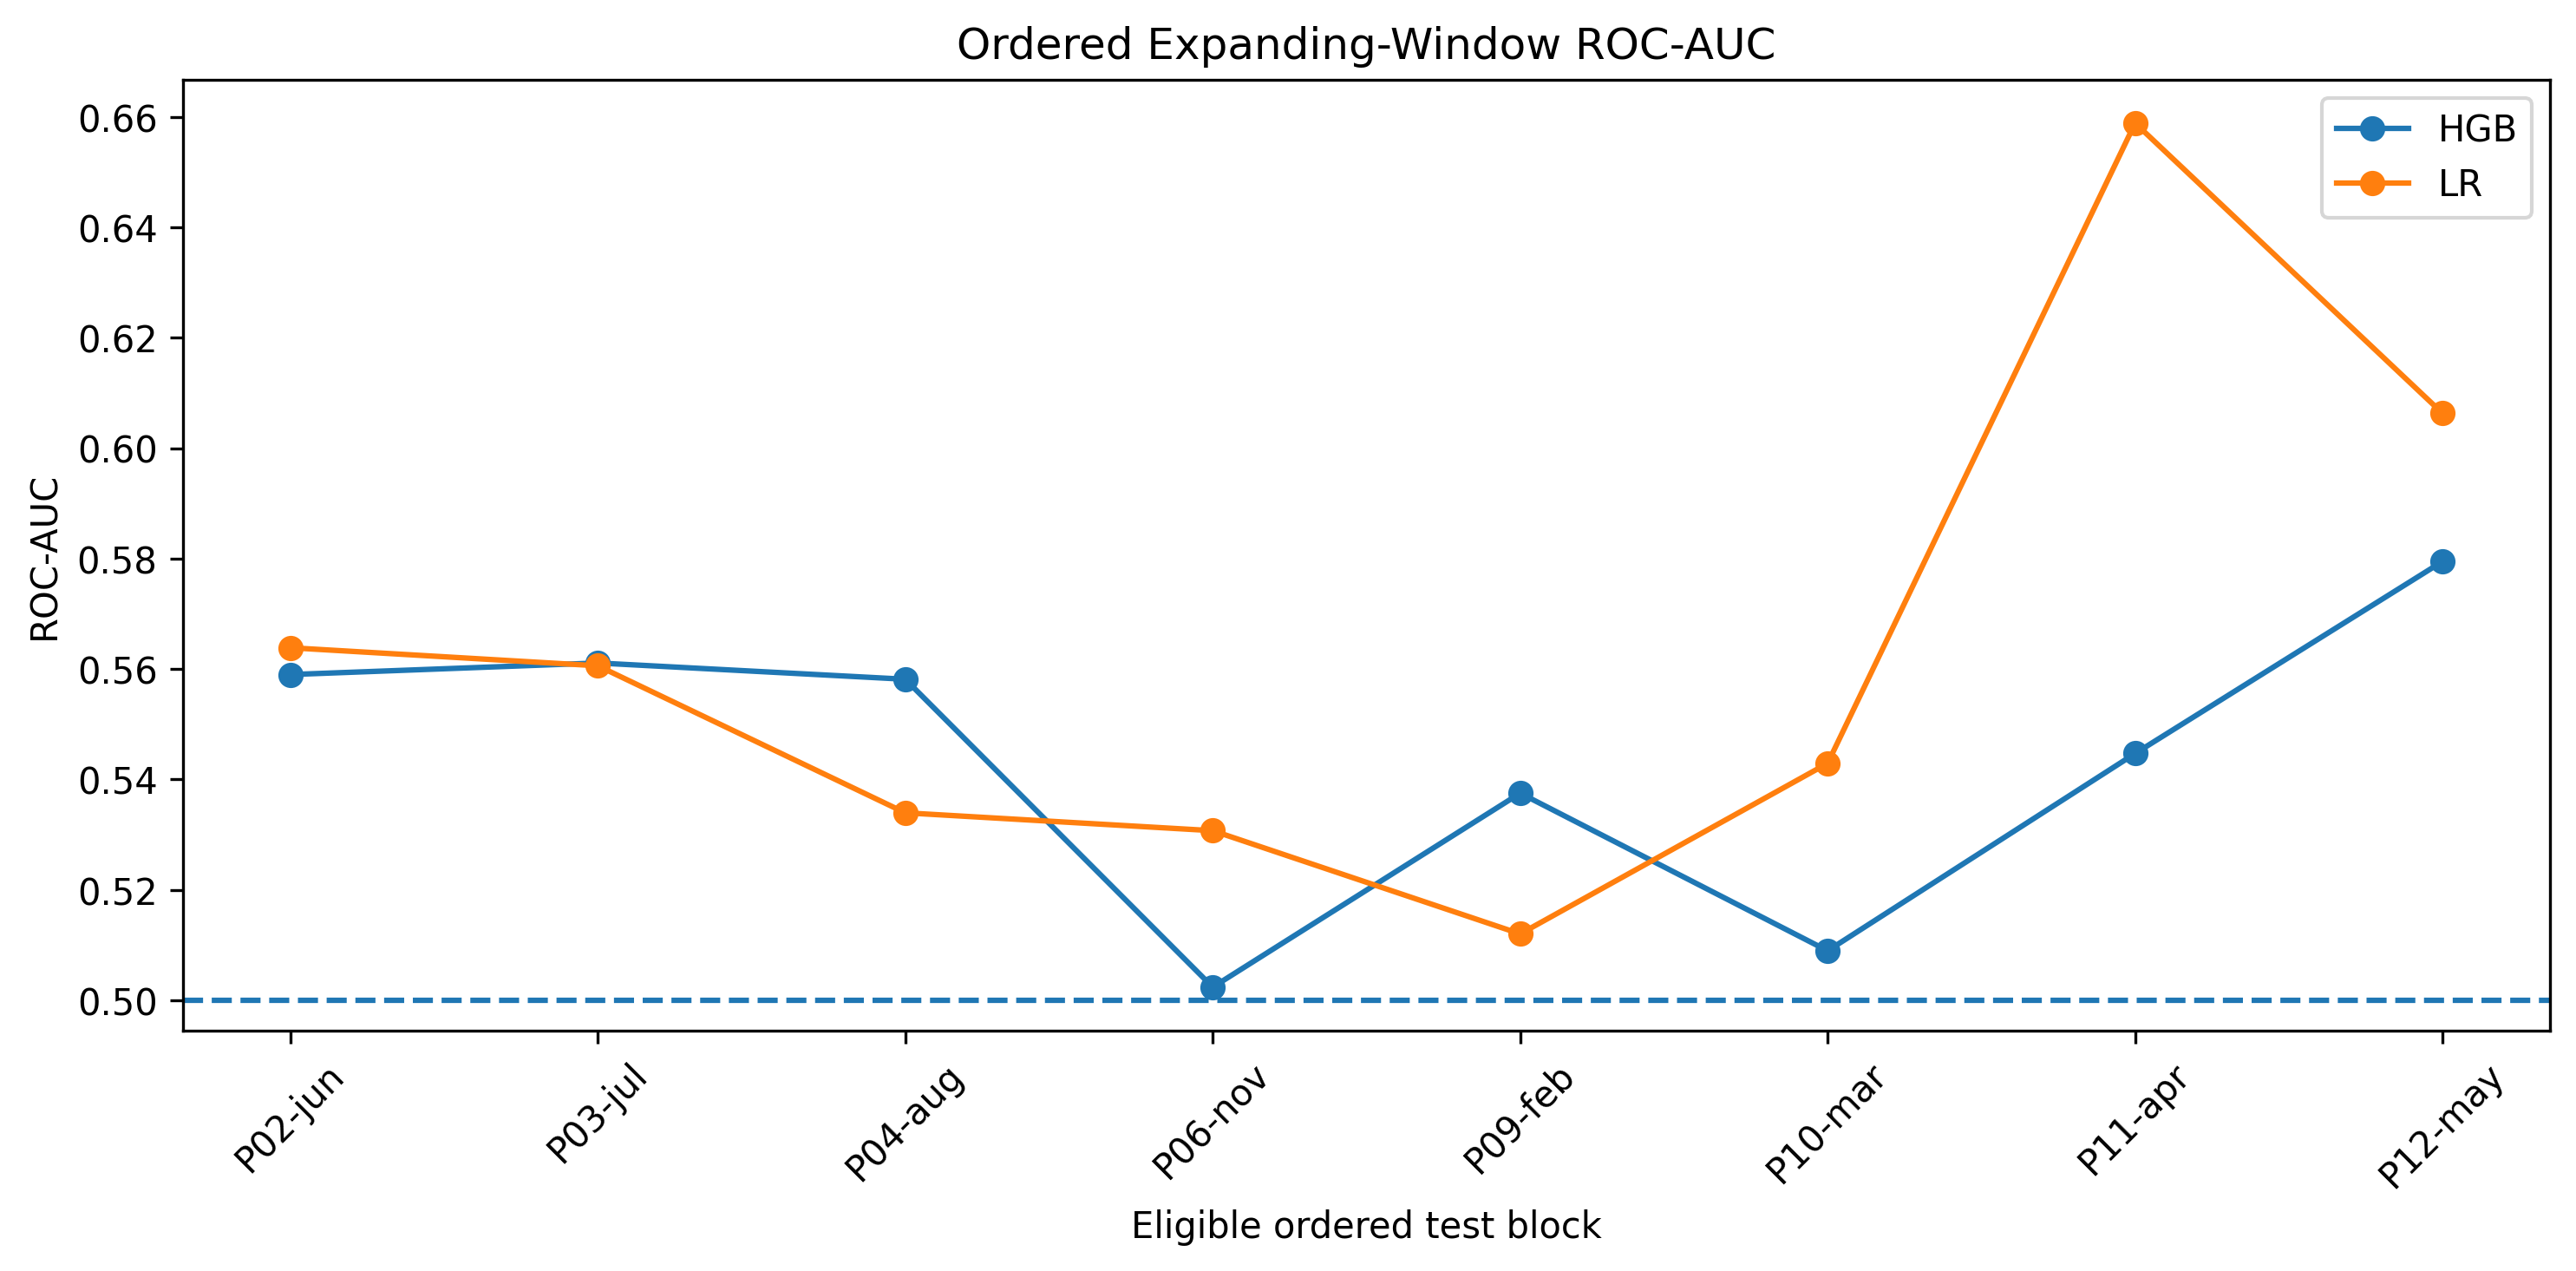

In [6]:
fig,ax=plt.subplots(figsize=(10,5))
for name,g in period_metrics.groupby('model'): ax.plot(g.period_label,g.roc_auc,marker='o',label=name)
ax.axhline(.5,linestyle='--'); ax.set(title='Ordered Expanding-Window ROC-AUC',xlabel='Eligible ordered test block',ylabel='ROC-AUC'); ax.tick_params(axis='x',rotation=45); ax.legend(); plt.tight_layout(); plt.savefig(FIG/'ordered_roc_auc.png',dpi=300,bbox_inches='tight'); plt.show()

## 6. Segment-versus-remainder uncertainty

In [7]:
slice_rows=[]
for name,g in predictions.groupby('model'):
    for pid,h in g.groupby('period_id'):
        for label,mask in [('Segment',h.segment),('Remainder',~h.segment)]:
            z=h[mask]
            if len(z)>1 and z.y_binary.nunique()==2: slice_rows.append({'model':name,'period_id':pid,'period_label':z.period_label.iloc[0],'slice':label,'n':len(z),'positives':int(z.y_binary.sum()),'base_rate':z.y_binary.mean(),'roc_auc':roc_auc_score(z.y_binary,z.score),'pr_auc':average_precision_score(z.y_binary,z.score)})
slices=pd.DataFrame(slice_rows); slices.to_csv(OUT/'segment_remainder_period_metrics.csv',index=False)
rng=np.random.default_rng(SEED); boot=[]
for name,g in slices.groupby('model'):
    p=g.pivot(index='period_id',columns='slice',values='roc_auc').dropna(); d=(p.Segment-p.Remainder).to_numpy(); reps=np.array([rng.choice(d,size=len(d),replace=True).mean() for _ in range(5000)]); boot.append({'model':name,'periods':len(d),'segment_mean_roc_auc':p.Segment.mean(),'remainder_mean_roc_auc':p.Remainder.mean(),'difference':d.mean(),'ci_lower':np.percentile(reps,2.5),'ci_upper':np.percentile(reps,97.5)})
segrob=pd.DataFrame(boot); segrob.to_csv(OUT/'segment_robustness.csv',index=False); display(segrob.round(4))

,model,periods,segment_mean_roc_auc,remainder_mean_roc_auc,difference,ci_lower,ci_upper
0,HGB,7,0.5456,0.5299,0.0157,-0.0174,0.0468
1,LR,7,0.5547,0.5632,-0.0086,-0.0430,0.0257
